In [1]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d

In [2]:
c = 299_792_458  # [m/s]

In [3]:
def gaussian(w, w0, sig):
    W = w - w0
    return np.exp(-0.5 * W**2 / sig**2)

def convert_w_to_l(func, w_range, *params):
    """
    w_range [rad/ps]
    """
    l_range = 2 * np.pi * c / w_range * 1e-3  # [nm]
    
    y_w = func(w_range, *params)
    y_l = y_w / l_range**2
    y_l /= np.max(y_l)

    return y_l

def gfit(pix, alpha, beta, shift, scale):
    wavelength = shift + scale * pix  # связь пикселя с длиной волны в [nm]

    C = 2 * np.pi * c * 1e-3
    ang_freq = C / wavelength  # [rad/ps]

    l0 = 810  # thorlabs BP filter 810/10
    l_fwhm = 10  # thorlabs BP filter 810/10 
    
    w0 = C / l0  # [rad/ps]
    w_fwhm = C * l_fwhm / (l0**2 - (l_fwhm/2)**2)
    sig_w = w_fwhm / 2 / np.sqrt(2 * np.log(2))
    
    y_l = convert_w_to_l(gaussian, ang_freq, w0, sig_w)
    y_l /= np.max(y_l)
    y_l = beta + alpha * y_l
    return y_l

In [4]:
names = [
    '4_CACO3_ANG0.00_FBP810-10d.png',
    '4_CACO3_ANG2.00_FBP810-10d.png',
    '4_CACO3_ANG4.00_FBP810-10d.png',
    '4_CACO3_ANGneg2.00_FBP810-10d.png',
    '4_CACO3_ANGneg4.00_FBP810-10d.png'
]

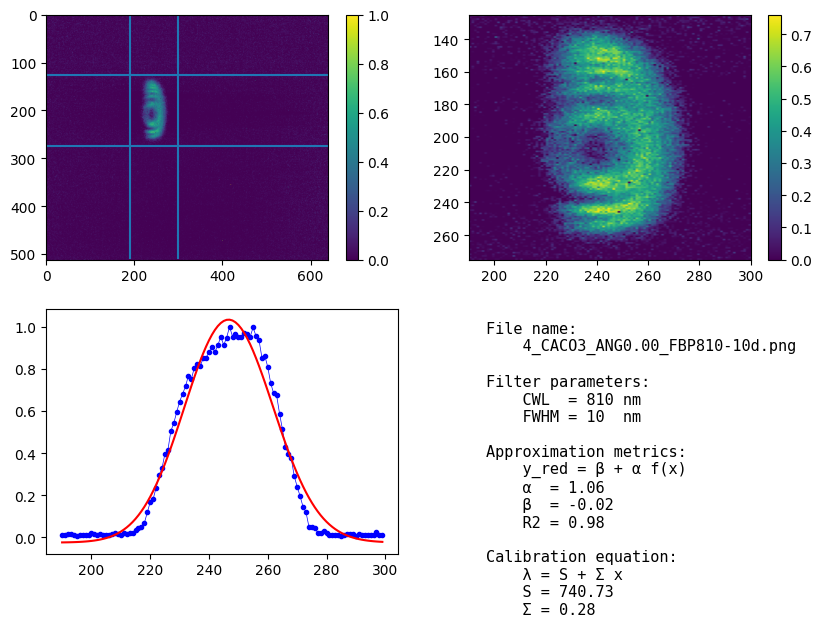

In [12]:
name = names[0]
imag = Image.open(name).convert('L')
imag = np.array(imag)
imag = imag / np.max(imag)

left, right, top, bottom = 190, 300, 125, 275
crop = imag[top: bottom, left: right]

x_pix = np.arange(left, right, 1)
y_exp = np.trapezoid(crop, axis=0)
y_exp /= np.max(y_exp)

alpha_0 = 1.0
beta_0 = 0.1
shift_0 = 743.39
scale_0 = 0.27
pinit = [alpha_0, beta_0, shift_0, scale_0]

popt, pcov = curve_fit(
    gfit,
    x_pix,
    y_exp,
    p0=pinit
)
alpha, beta, shift, scale = popt

y_th = gfit(x_pix, *popt)
r2 = r2_score(y_exp, y_th)

info = f"""File name:
    {name}

Filter parameters:
    CWL  = 810 nm
    FWHM = 10  nm

Approximation metrics:
    y_red = β + α f(x)
    α  = {alpha:.2f}
    β  = {beta:.2f}
    R2 = {r2:.2f}

Calibration equation:
    λ = S + Σ x
    S = {shift:.2f}
    Σ = {scale:.2f}
"""


fig, ax = plt.subplots(2, 2, figsize=(10, 7))

im0 = ax[0, 0].imshow(imag, aspect='auto')
ax[0, 0].vlines(left, 0, 511)
ax[0, 0].vlines(right, 0, 511)
ax[0, 0].hlines(top, 0, 639)
ax[0, 0].hlines(bottom, 0, 639)
fig.colorbar(im0, ax=ax[0, 0])

im1 = ax[0, 1].imshow(
    crop, 
    extent=[
        left, right, bottom, top
    ],
    aspect='auto'
)
fig.colorbar(im1, ax=ax[0, 1])

ax[1, 0].plot(
    x_pix, y_exp,
    marker = '.',
    linewidth = 0.5,
    color = 'blue'
)
ax[1, 0].plot(
    x_pix, y_th,
    color = 'red'
)

ax[1, 1].axis('off')
ax[1, 1].text(
    0.05, 0.95, info,
    transform=ax[1, 1].transAxes,
    va='top',
    family='monospace',
    fontsize=11
)

plt.show()

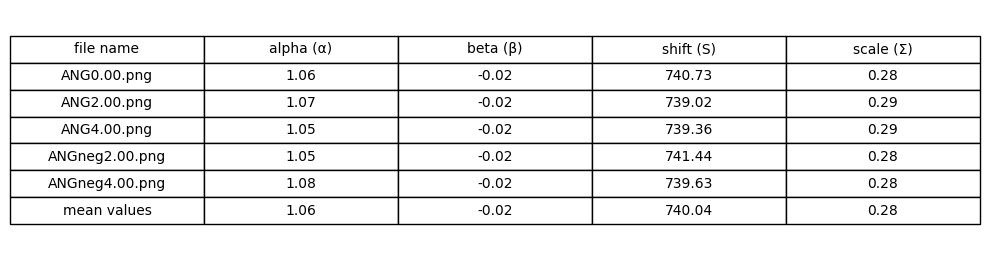

In [16]:
rows = []
values = []

if (left is None) and (top is None):
    left, right, top, bottom = 190, 300, 125, 275
x_pix = np.arange(left, right, 1)

if pinit is None:
    pinit = [1.0, 0.1, 761, 0.2]

for name in names:
    imag = Image.open(name).convert('L')
    imag = np.array(imag)
    imag = imag / np.max(imag)

    crop = imag[top: bottom, left: right]

    y_exp = np.trapezoid(crop, axis=0)
    y_exp /= np.max(y_exp)

    popt, pcov = curve_fit(
        gfit,
        x_pix,
        y_exp,
        p0=pinit
    )

    alpha, beta, shift, scale = popt
    values.append([alpha, beta, shift, scale])

    rows.append([
        name.replace('4_CACO3_', '').replace('_FBP810-10d', ''),
        f'{alpha:.2f}',
        f'{beta:.2f}',
        f'{shift:.2f}',
        f'{scale:.2f}'
    ])

mean_values = np.mean(values, axis=0)

rows.append([
    'mean values',
    f'{mean_values[0]:.2f}',
    f'{mean_values[1]:.2f}',
    f'{mean_values[2]:.2f}',
    f'{mean_values[3]:.2f}'
])

fig, ax = plt.subplots(figsize=(10, 0.6 + 0.35 * len(rows)))
ax.axis('off')

table = ax.table(
    cellText=rows,
    colLabels=['file name', 'alpha (α)', 'beta (β)', 'shift (S)', 'scale (Σ)'],
    loc='center',
    cellLoc='center',
    colLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.tight_layout()
plt.show()